In [1]:
import numpy as np
from scipy import special
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, SymLogNorm
import matplotlib.tri as tri
import auxiliary_funcs as af
import parameters as p


tau_o ions = 2123.1766532800625
ZPAR = 233.3333333333333 should match 233.33
ZPERP = 0.03055752047819377


# ERF/SLP FUNCS

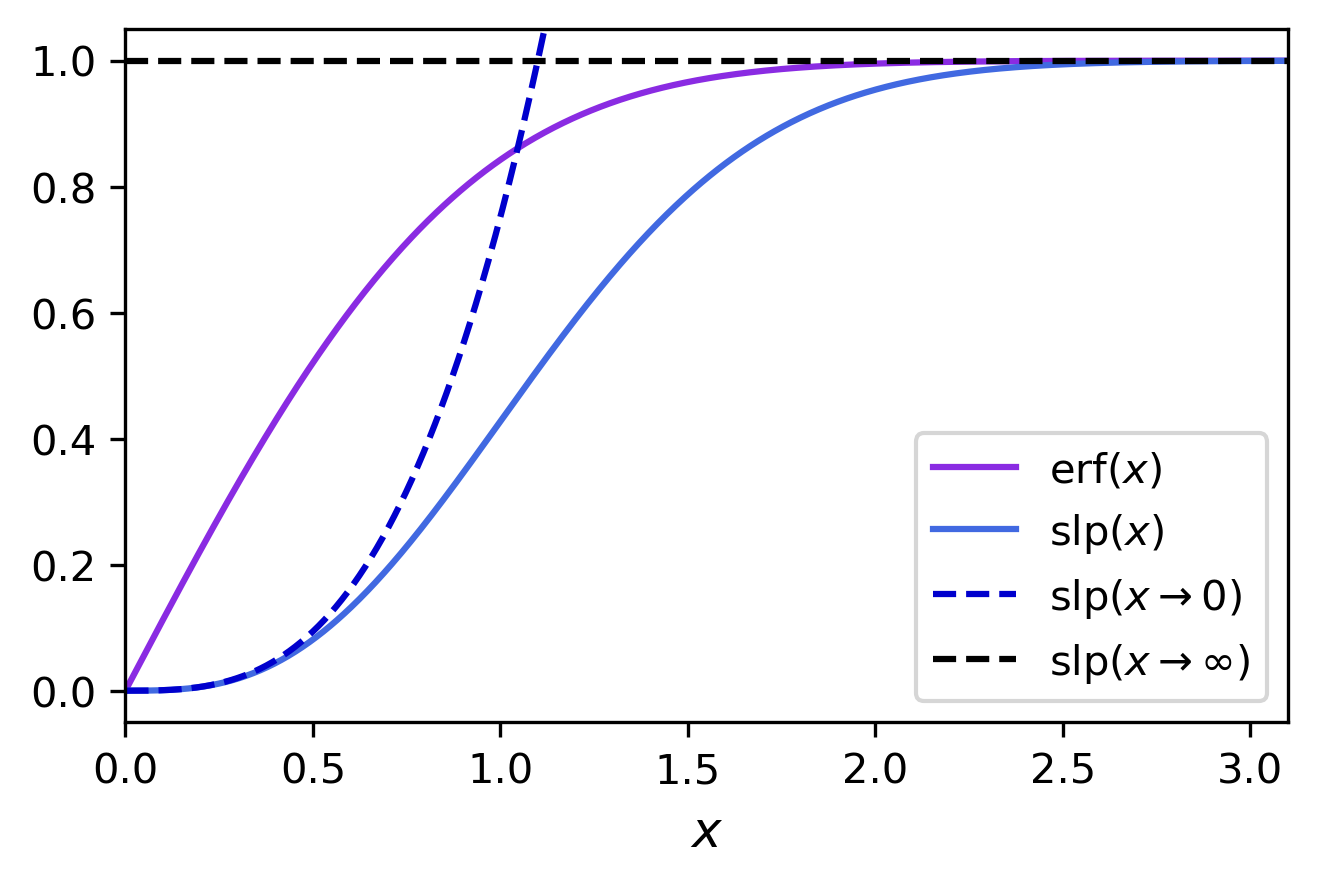

In [163]:
x = np.linspace(0, 3.1, 1000)

plt.figure(figsize=(5, 3), dpi=300)
plt.xlabel(r'$x$', fontsize=12)
plt.xlim(0, 3.1)
plt.ylim(-0.05, 1.05)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.plot(x, special.erf(x), label=r'erf$\left(x\right)$', color='blueviolet')
plt.plot(x, af.slp(x), label=r'slp$\left(x\right)$', color='royalblue')
plt.plot(x, 4 / (3 * np.sqrt(np.pi)) * x**3, label=r'slp$\left(x \rightarrow 0\right)$', linestyle='--', color='mediumblue')
plt.axhline(1, linestyle='--', color='black', label=r'slp$\left(x\rightarrow \infty \right) $')
plt.legend(fontsize=10)
plt.show()

# ALEJANDRO TEMPERATURE 

In [2]:
print(f'check approach 1 wparslp {af.wparb_slp(15)}')
print(f'check approach 1 wperpslp {af.wperpb_erf(15)}')
print(f'check approach 1 wbslp {af.wb_slp(15)}')

check approach 1 wparslp 0.9975988414316777
check approach 1 wperpslp 0.9999228357972935
check approach 1 wbslp 0.9975988414316777


In [3]:
# ASIM X FUNCTIONS
def Asimx(x): 
    A_a = - p.ZPAR * af.wparb_slp(x) / x**2 
    A_geom = - af.wb_slp(x) / (2 * x**4) + 2 / (x * np.sqrt(np.pi)) * af.wb_exp(x)
    return A_a + A_geom

def Asimx_nogeom(x): 
    return - p.ZPAR * af.wparb_slp(x) / x**2 


AttributeError: module 'auxiliary_funcs' has no attribute 'wb_exp'

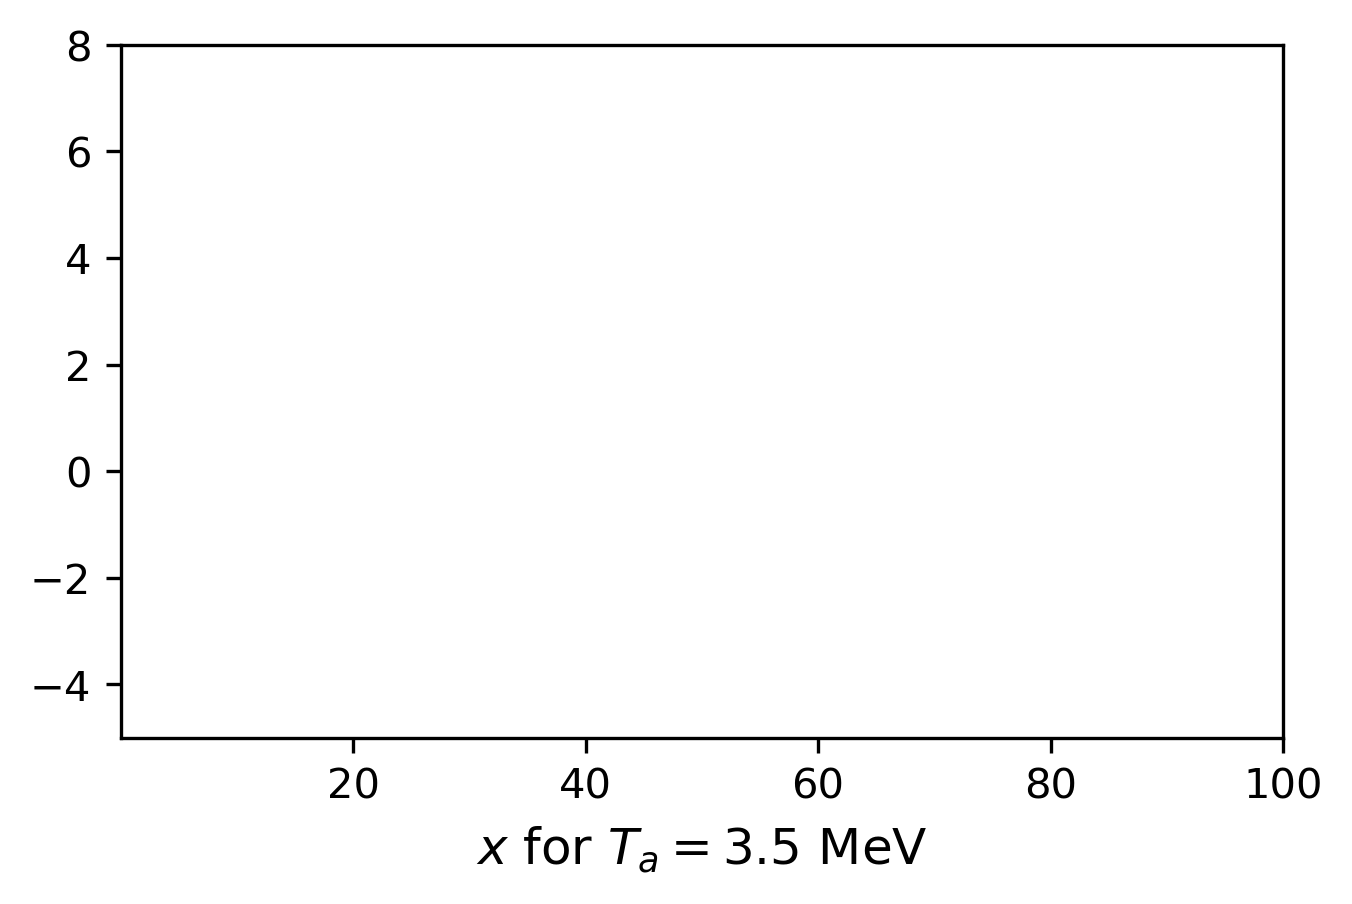

In [4]:
# PLOTS 
# x = np.linspace(1e-5, 100, 1000)
x = np.logspace(-5, 2, 1000)

plt.figure(figsize=(5, 3), dpi=300)
plt.xlabel(r'$x$ for $T_a = 3.5~\text{MeV}$', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(-5, 8)
plt.xlim(1e-5, 100)
plt.plot(x, Asimx(x), color='mediumblue', label=r'A$_{\text{sim}}^x$', linewidth=2)
plt.plot(x, Asimx_nogeom(x), color='mediumvioletred', label=r'A$_{a}^x$ (no correction)', linewidth=2, linestyle='--')
plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.axvline(0.1, linestyle=':', color='black', linewidth=1, label=r'$x=0.1$')
plt.xscale('log')
plt.legend(fontsize=10)
plt.show()

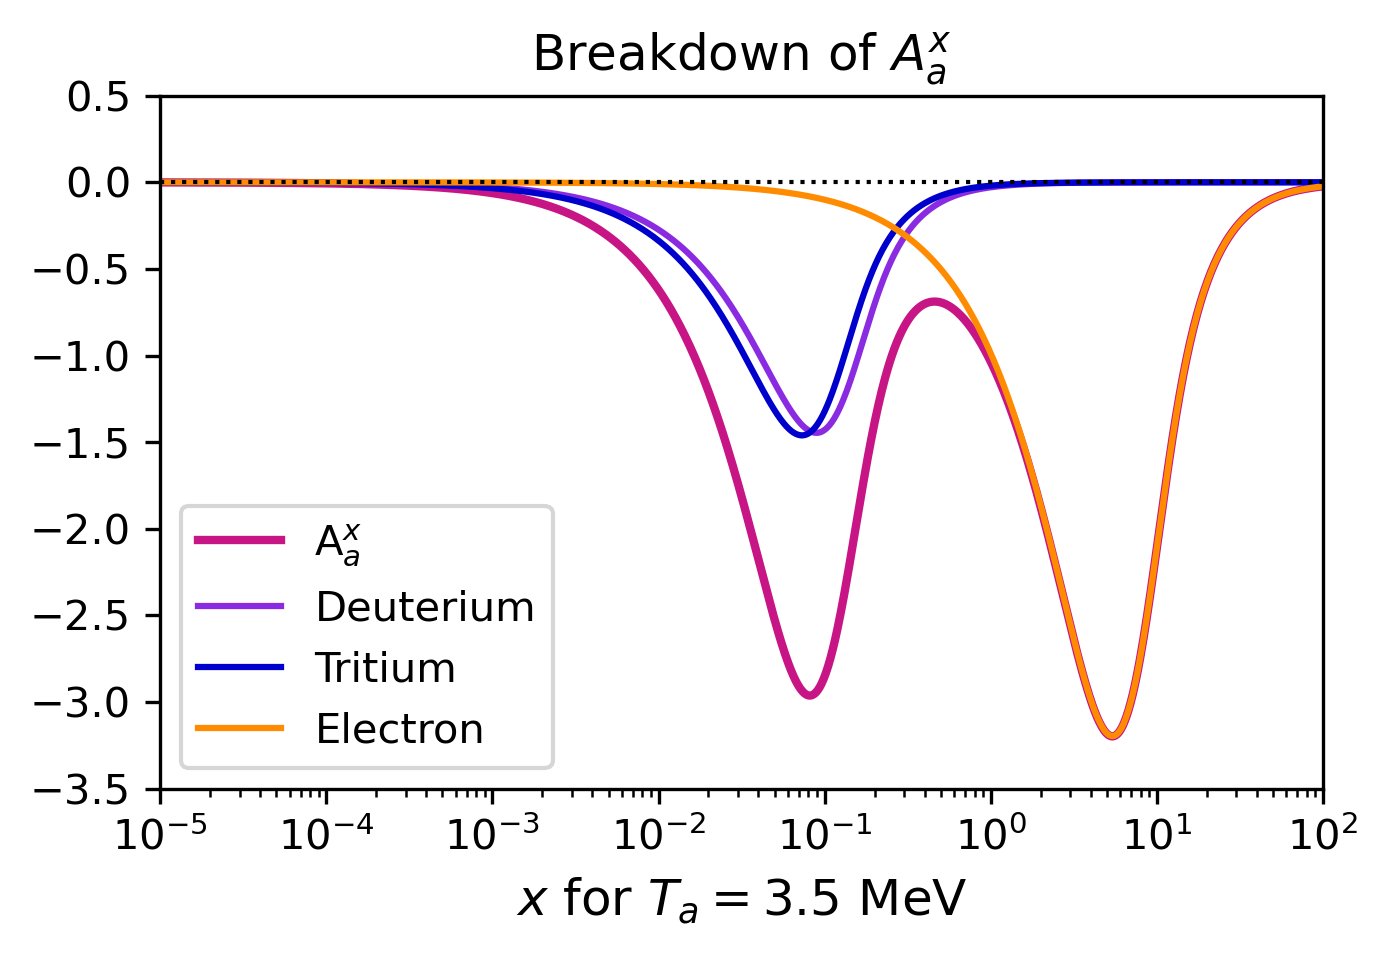

In [5]:
# x = np.linspace(1e-5, 100, 1000)
x = np.logspace(-5, 2, 1000)

plt.figure(figsize=(5, 3), dpi=300)
plt.xlabel(r'$x$ for $T_a = 3.5~\text{MeV}$', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(-3.5, 0.5)
plt.xlim(1e-5, 100)
plt.plot(x, Asimx_nogeom(x), color='mediumvioletred', label=r'A$_{a}^x$', linewidth=2)
plt.plot(x, -p.ZPAR * af.slp(x * p.V_TH_A/p.V_TH_D) * p.C_ad/p.MASS_DEUT / p.WPAR_B_DEN / x**2, label=r'Deuterium', color='blueviolet')
plt.plot(x, -p.ZPAR * af.slp(x * p.V_TH_A/p.V_TH_T) * p.C_at/p.MASS_TRIT / p.WPAR_B_DEN / x**2, label=r'Tritium', color='mediumblue')
plt.plot(x, -p.ZPAR * af.slp(x * p.V_TH_A/p.V_TH_E) * p.C_ae/p.MASS_ELEC / p.WPAR_B_DEN / x**2, label=r'Electron', color='darkorange')
plt.axhline(0, linestyle=':', color='black', linewidth=1)
plt.xscale('log')
plt.legend(fontsize=10)
plt.title(r'Breakdown of $A^x_a$', fontsize=12)
plt.show()

In [6]:
def Asimxi(x,xi=0.5): 
    return - 2 * xi / x**3 * (p.ZPERP * af.wperpb_erf(x) - 1 / (4 * x**2) * af.wb_slp(x))

def Asimhighxi(x,xi=0.5): 
    return - 2 * p.ZPERP * xi / x**3

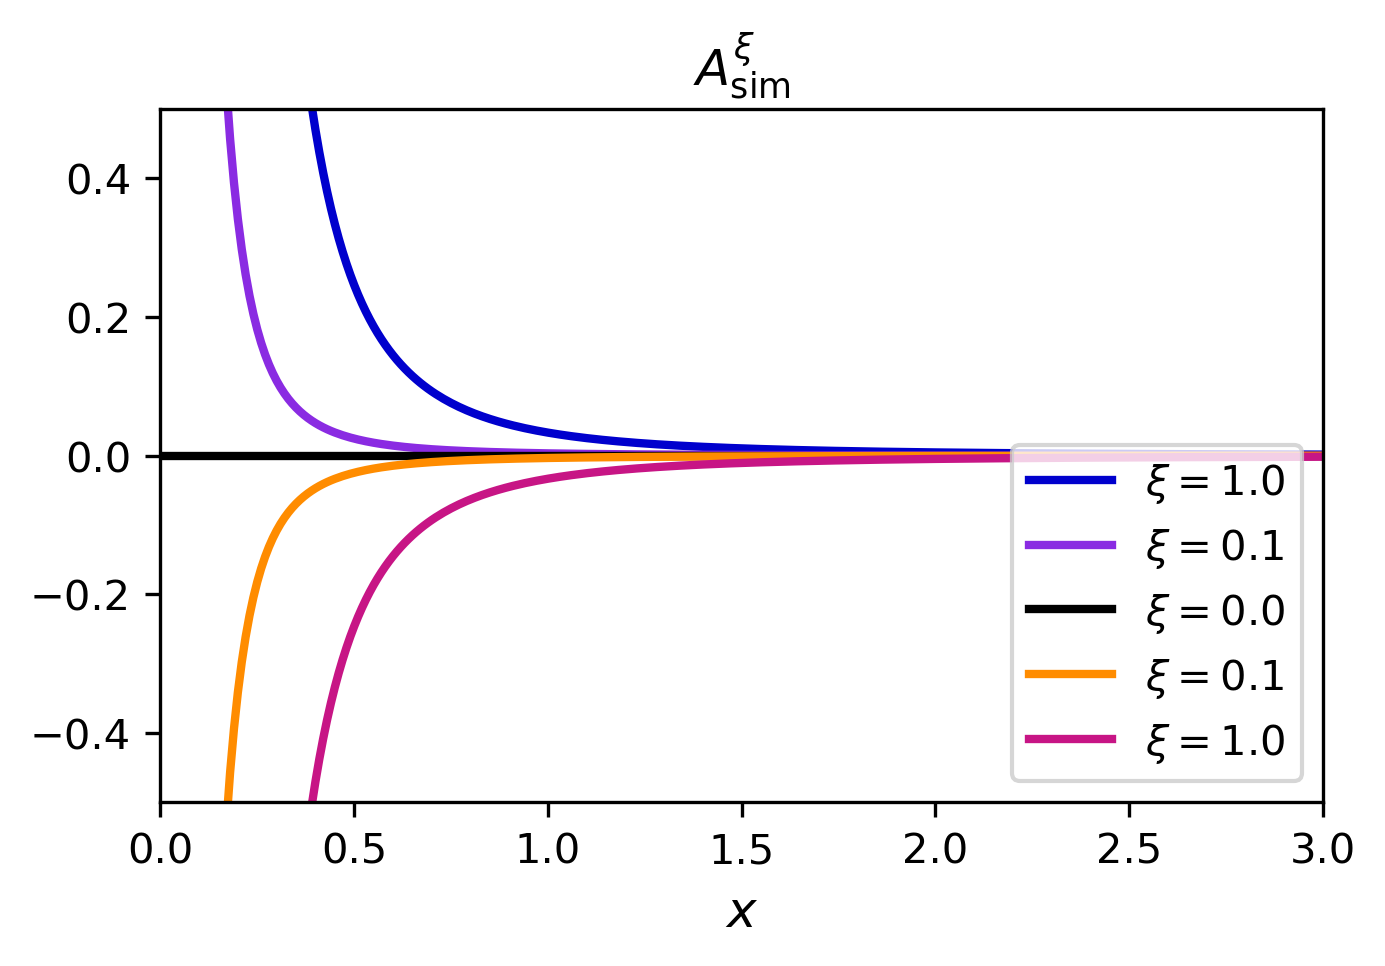

In [7]:
# plot, different values, -1, -0.5, 0, 0.5, 1, red, orange black purple blue
xvals = np.linspace(1e-8, 10, 1000)
plt.figure(figsize=(5, 3), dpi=300)
plt.xlabel(r'$x$', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0,3)
plt.ylim(-0.5, 0.5)
plt.plot(xvals, Asimxi(xvals, xi=-1.0), color='mediumblue', label=r'$\xi=1.0$', linewidth=2)
plt.plot(xvals, Asimxi(xvals, xi=-0.1), color='blueviolet', label=r'$\xi=0.1$', linewidth=2)
plt.axhline(0, color='black', linewidth=2, label=r'$\xi=0.0$')
plt.plot(xvals, Asimxi(xvals, xi=0.1), color='darkorange', label=r'$\xi=0.1$', linewidth=2)
plt.plot(xvals, Asimxi(xvals, xi=1.0), color='mediumvioletred', label=r'$\xi=1.0$', linewidth=2)
plt.legend(fontsize=10, loc='lower right')
plt.title(r'$A_\text{sim}^\xi$', fontsize=12)
plt.show()


/var/folders/5l/cp2w2dsj569686mqpbzbm61c0000gn/T/ipykernel_24725/3215157465.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('RdBu_r', n_bins)
/Users/gretali/miniforge3/envs/alphachanneling/lib/python3.10/site-packages/matplotlib/tri/_triangulation.py:181: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


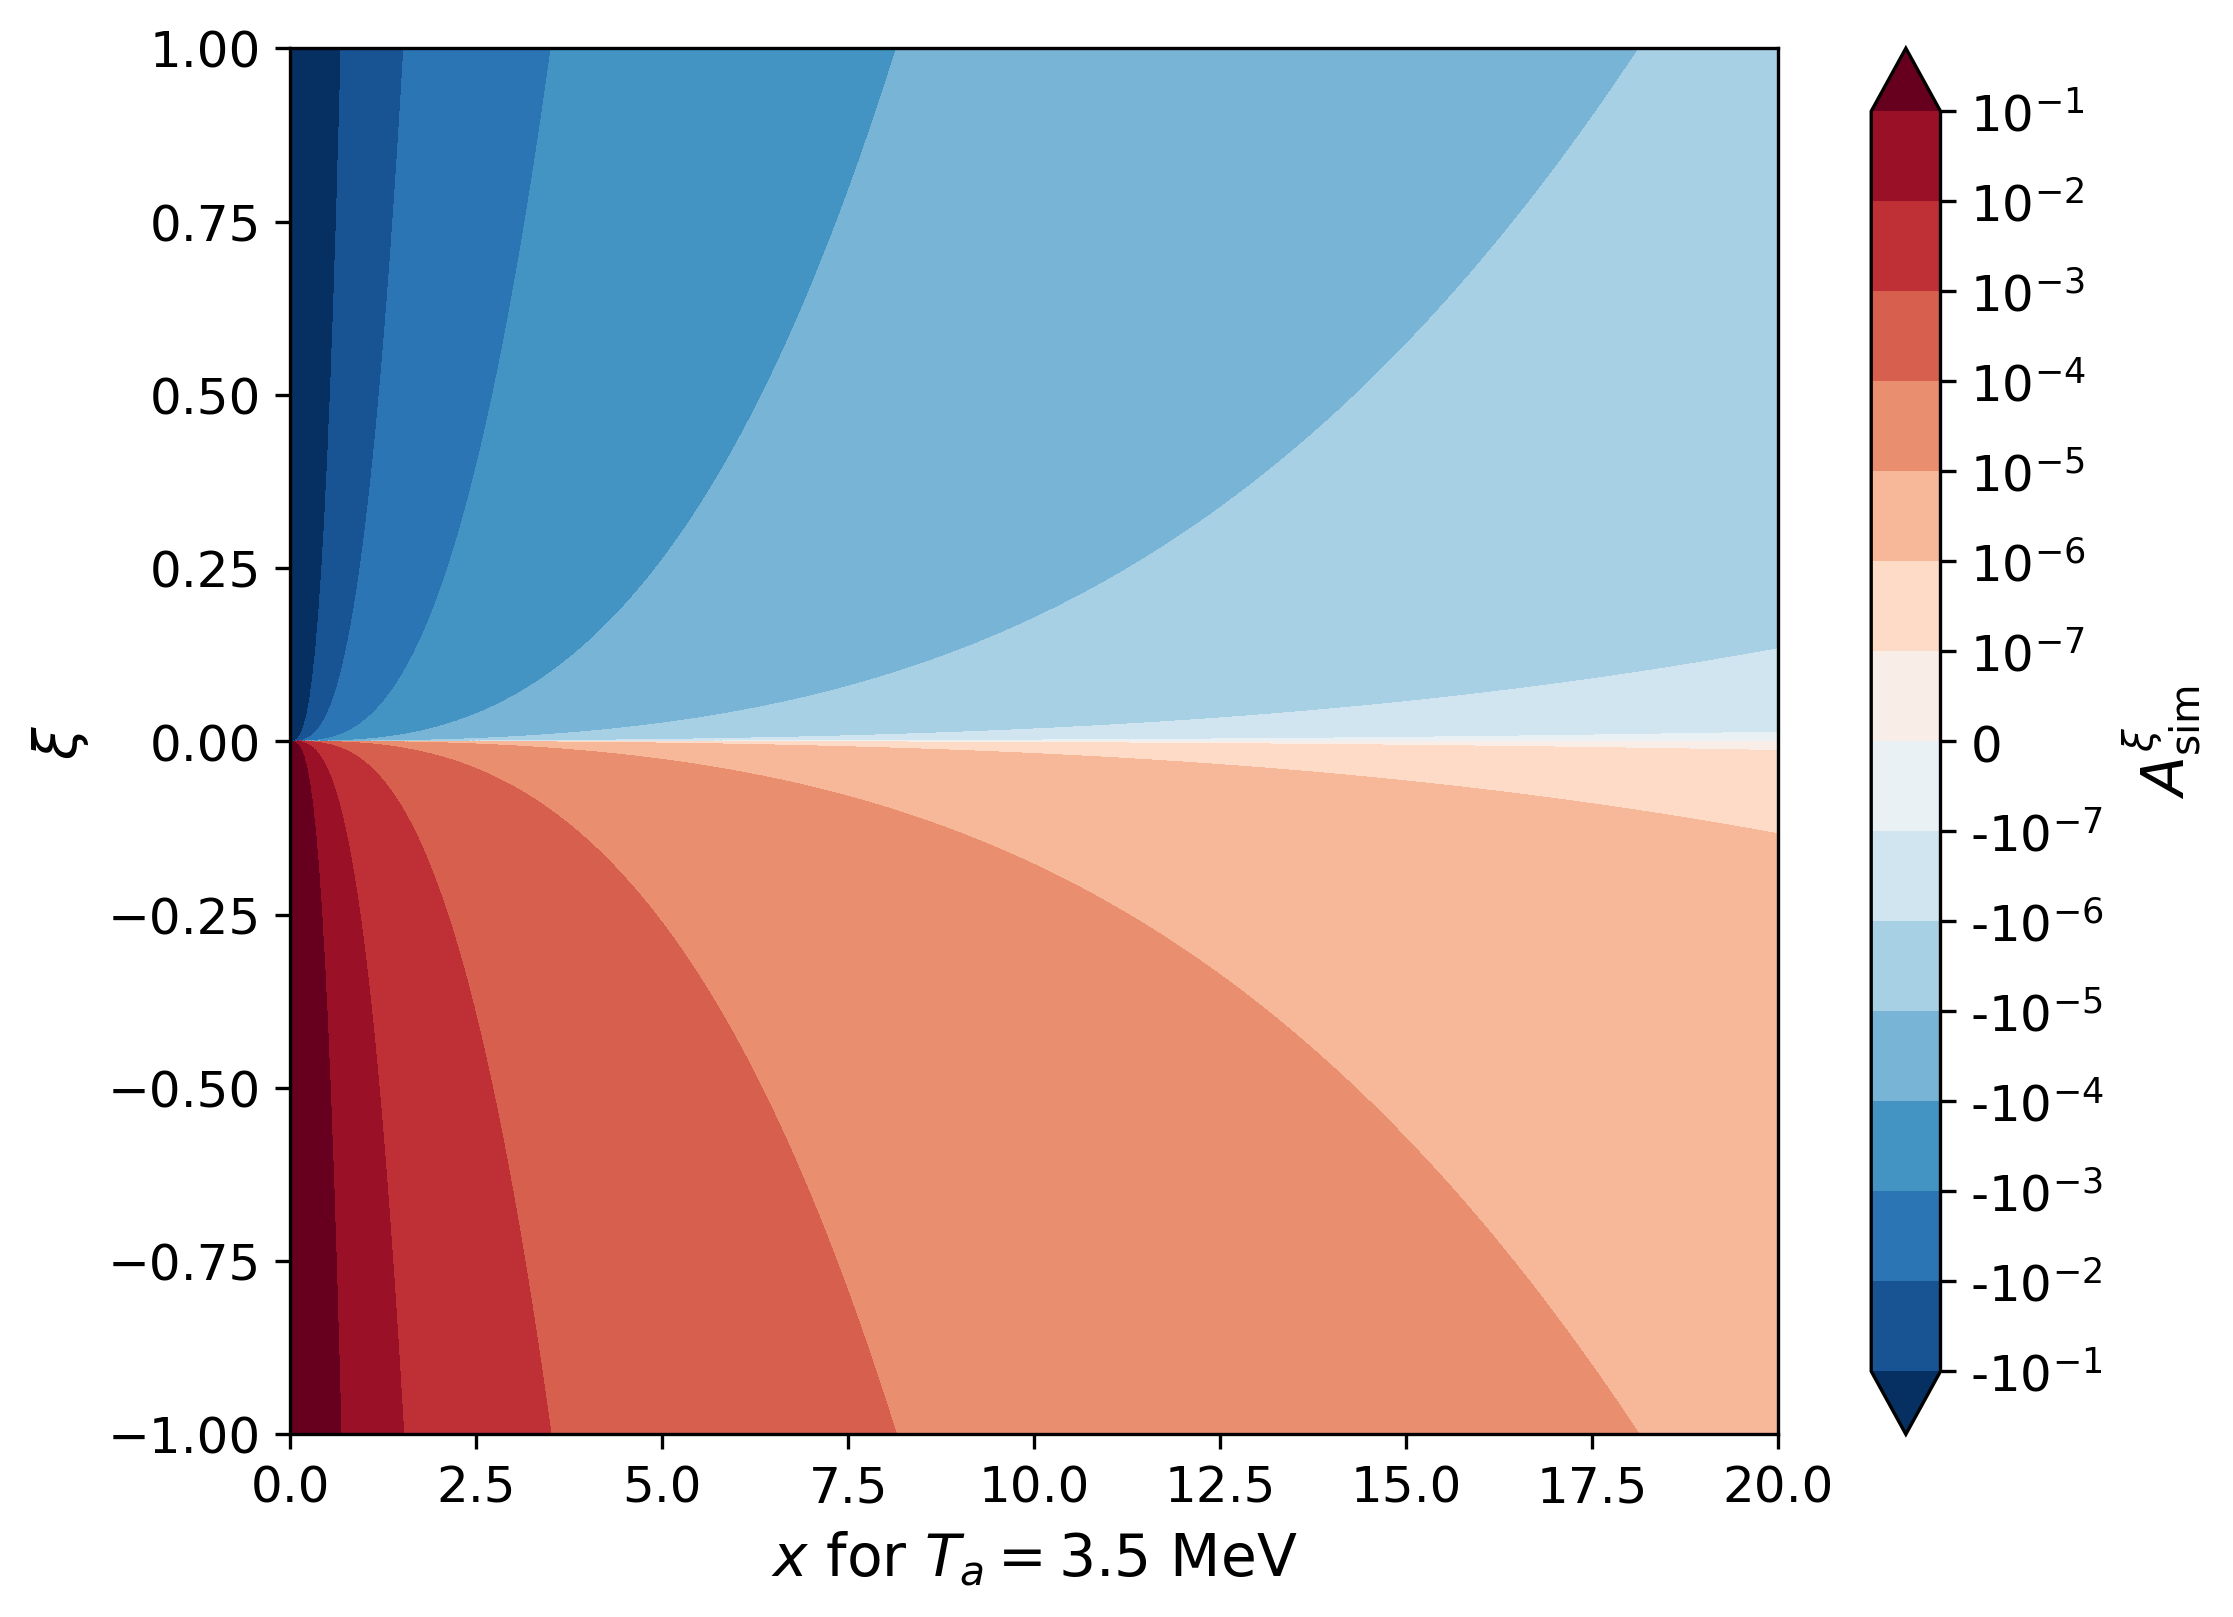

In [12]:
levels = np.array([-1e-1,-1e-2, -1e-3, -1e-4, -1e-5, -1e-6, -1e-7, 0.0, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])
n_bins = len(levels) + 1
base_cmap = plt.cm.get_cmap('RdBu_r', n_bins)
normed_bounds = (levels - levels.min()) / (levels.max() - levels.min())
colors = base_cmap(np.linspace(0, 1, n_bins))
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=levels, ncolors=n_bins, extend='both')

x_values = np.linspace(1e-10, 20, 500)  
xi_values = np.linspace(-1, 1, 500)
X, XI = np.meshgrid(x_values, xi_values)
Z = Asimxi(X, XI) 
x_flat = X.flatten()
xi_flat = XI.flatten()
z_flat = Z.flatten()

plt.figure(figsize=(8,6), dpi=300)
tri = plt.tricontourf(x_flat, xi_flat, z_flat, cmap=cmap, norm=norm, levels=levels, extend='both')
cbar = plt.colorbar(tri, extend='both', ticks=levels)
tick_labels = [r'$0$' if v==0 else f'$10^{{{int(np.log10(abs(v)))}}}$' for v in levels]
tick_labels = [label if v>=0 else '-' + label for v, label in zip(levels, tick_labels)]
cbar.set_ticklabels(tick_labels, fontsize=12)
cbar.set_label(label=r'$A_\text{sim}^{\xi}$', fontsize=14)
plt.xlabel(r'$x$ for $T_a = 3.5~\text{MeV}$', fontsize=14)
plt.ylabel(r'$\xi$', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

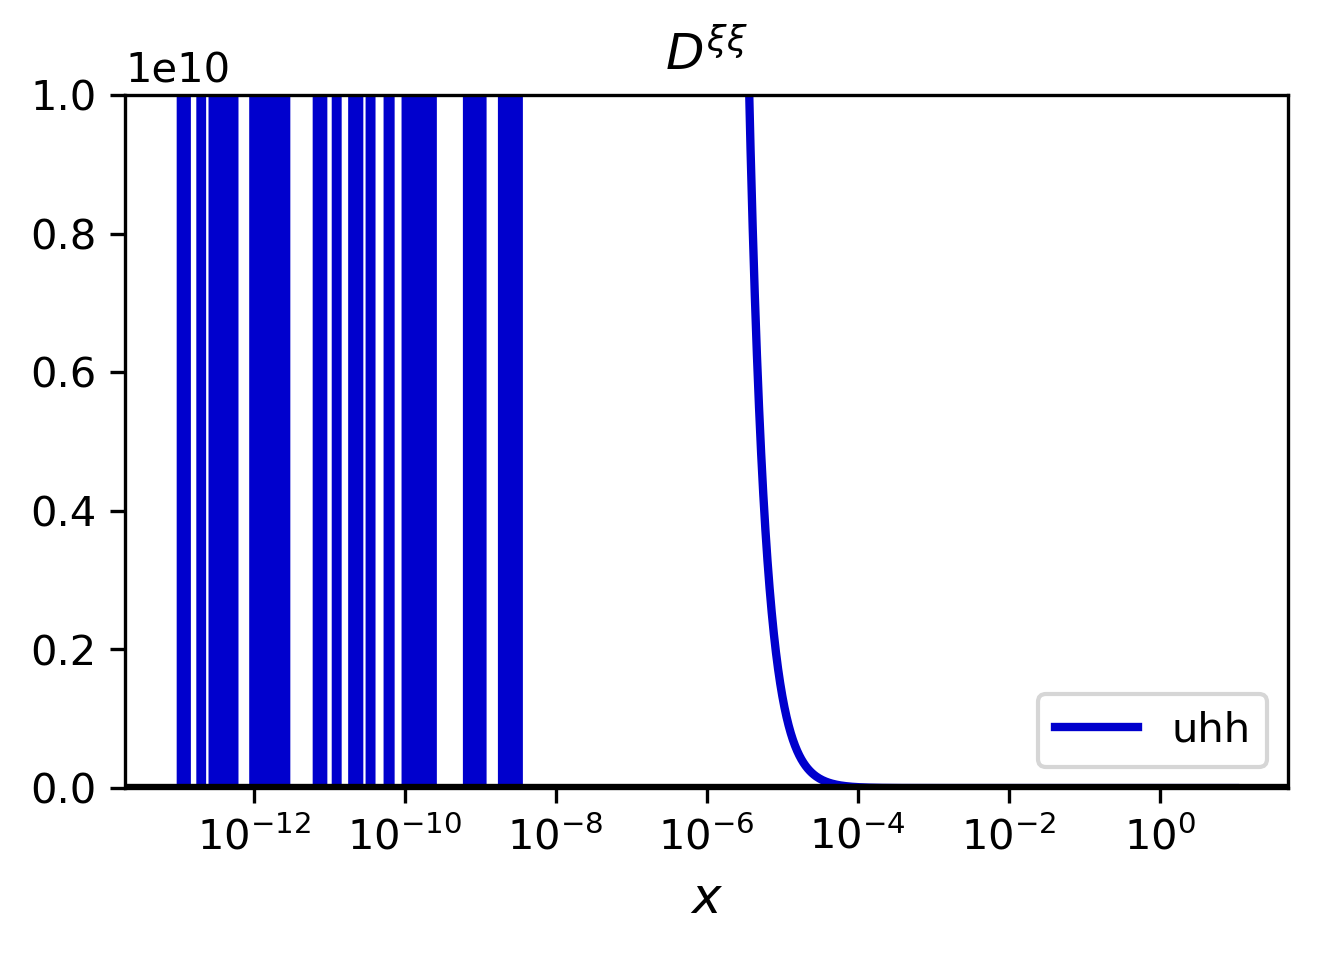

In [20]:
# plot Dxixi term 
def Dxixi(x): 
    return 1 / x**3 * (p.ZPERP * af.wperpb_erf(x) - 1 / (4 * x**2) * af.wb_slp(x))

# def Dxixi_reg(x): 
#     return 1 / (x+1e-10)**3 * (p.ZPERP * af.wperpb_erf(x) - 1 / (4 * x**2) * af.wb_slp(x))

xvals = np.logspace(-13, 1, 1000)
plt.figure(figsize=(5, 3), dpi=300)
plt.xlabel(r'$x$', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(-1, 1e10)
plt.plot(xvals, Dxixi(xvals), color='mediumblue', label=r'uhh', linewidth=2)
# plt.plot(xvals, Dxixi_reg(xvals), color='darkorange', label=r'reg', linewidth=2)
plt.xscale('log')
plt.axhline(0, color='black', linewidth=2)
plt.legend(fontsize=10, loc='lower right')
plt.title(r'$D^{\xi\xi}$', fontsize=12)
plt.show()


# SAME TEMPERATURE

In [12]:
# CONSTANTS  
e = 4.8e-10 # elementary charge in statcoulombs
eV_to_erg = 1.60218e-12

N_ALPHA = 0.3e13 # cm-3
Z_ALPHA = 2 
CHARGE_ALPHA = 2*e # statC
MASS_ALPHA = 6.64e-24 # g
TEMP_ALPHA = 15e3 * eV_to_erg # eV 

N_DEUT = 4.85e13 # cm-3
Z_DEUT = 1
CHARGE_DEUT = e # statC
MASS_DEUT = 3.34e-24 # g
TEMP_DEUT = 15e3 * eV_to_erg # eV 

N_TRIT = 4.85e13 # cm-3
Z_TRIT = 1
CHARGE_TRIT = e # statC
MASS_TRIT = 5.0e-24 # g
TEMP_TRIT = 15e3 * eV_to_erg # eV

N_ELEC = 1.30e14 # cm-3 
CHARGE_ELEC = e # statC
MASS_ELEC = 9.11e-28 # g
Z_ELEC = -1 
TEMP_ELEC = 15e3 * eV_to_erg # eV 

LAMBDA_AD = 24.686 # these values are kind of on the high side, would expect around 15? as a typical value.  
LAMBDA_AT = 24.934 
LAMBDA_AE = 20.355

In [13]:
# AUXILIARY QUANTITIES 
C_ad = 4 * np.pi * N_DEUT * MASS_ALPHA * Z_ALPHA**2 * Z_DEUT**2 * e**4 * LAMBDA_AD # essentially charge **2 for each species? 
C_at = 4 * np.pi * N_TRIT * MASS_ALPHA * Z_ALPHA**2 * Z_TRIT**2 * e**4 * LAMBDA_AT
C_ae = 4 * np.pi * N_ELEC * MASS_ALPHA * Z_ALPHA**2 * Z_ELEC**2 * e**4 * LAMBDA_AE

V_TH_A = np.sqrt(2 * TEMP_ALPHA/MASS_ALPHA)
V_TH_D = np.sqrt(2 * TEMP_DEUT/MASS_DEUT)
V_TH_T = np.sqrt(2 * TEMP_TRIT/MASS_TRIT)
V_TH_E = np.sqrt(2 * TEMP_ELEC/MASS_ELEC)

TAU_oi = ((C_ad * TEMP_DEUT) / (MASS_DEUT * MASS_ALPHA**2 * V_TH_A**3 * TEMP_ALPHA) \
        + (C_at * TEMP_TRIT) / (MASS_TRIT * MASS_ALPHA**2 * V_TH_A**3 * TEMP_ALPHA) ) ** -1
print(f'tau_o ions = {TAU_oi}')

ZPAR_NUM = N_DEUT * Z_DEUT**2 * LAMBDA_AD / MASS_DEUT \
         + N_TRIT * Z_TRIT**2 * LAMBDA_AT / MASS_TRIT \
         + N_ELEC * Z_ELEC**2 * LAMBDA_AE / MASS_ELEC
ZPAR_DEN = N_DEUT * Z_DEUT**2 * LAMBDA_AD * TEMP_DEUT / (MASS_DEUT * TEMP_ALPHA) \
         + N_TRIT * Z_TRIT**2 * LAMBDA_AT * TEMP_TRIT / (MASS_TRIT * TEMP_ALPHA) \
         + N_ELEC * Z_ELEC**2 * LAMBDA_AE * TEMP_ELEC / (MASS_ELEC * TEMP_ALPHA) 
ZPAR = ZPAR_NUM / ZPAR_DEN
print(f'ZPAR = {ZPAR} should match 1')

ZPERP_NUM = N_DEUT * Z_DEUT**2 * LAMBDA_AD \
          + N_TRIT * Z_TRIT**2 * LAMBDA_AT \
          + N_ELEC * Z_ELEC**2 * LAMBDA_AE
ZPERP_DEN = N_DEUT * Z_DEUT**2 * LAMBDA_AD * MASS_ALPHA * TEMP_DEUT / (MASS_DEUT * TEMP_ALPHA) \
          + N_TRIT * Z_TRIT**2 * LAMBDA_AT * MASS_ALPHA * TEMP_TRIT / (MASS_TRIT * TEMP_ALPHA) \
          + N_ELEC * Z_ELEC**2 * LAMBDA_AE * MASS_ALPHA * TEMP_ELEC / (MASS_ELEC * TEMP_ALPHA)
ZPERP = 0.5 * ZPERP_NUM/ZPERP_DEN
print(f'ZPERP = {ZPERP}')

WB_DEN = C_ad * TEMP_DEUT / MASS_DEUT \
       + C_at * TEMP_TRIT / MASS_TRIT \
       + C_ae * TEMP_ELEC / MASS_ELEC 
WPERP_B_DEN = C_ad + C_at + C_ae
WPAR_B_DEN = C_ad / MASS_DEUT \
           + C_at / MASS_TRIT \
           + C_ae / MASS_ELEC 

wparbslp = lambda x: (slp(x * V_TH_A/V_TH_D) * C_ad/MASS_DEUT 
                    + slp(x * V_TH_A/V_TH_T) * C_at/MASS_TRIT
                    + slp(x * V_TH_A/V_TH_E) * C_ae/MASS_ELEC) / WPAR_B_DEN

wbslp = lambda x: (slp(x * V_TH_A/V_TH_D) * C_ad * TEMP_DEUT / MASS_DEUT 
                 + slp(x * V_TH_A/V_TH_T) * C_at * TEMP_TRIT / MASS_TRIT
                 + slp(x * V_TH_A/V_TH_E) * C_ae * TEMP_ELEC / MASS_ELEC) / WB_DEN

wbexp_simx = lambda x: (np.exp(-(x * V_TH_A/V_TH_D)**2) * (V_TH_A/V_TH_D)**3 * C_ad * TEMP_DEUT / MASS_DEUT 
                      + np.exp(-(x * V_TH_A/V_TH_T)**2) * (V_TH_A/V_TH_T)**3 * C_at * TEMP_TRIT / MASS_TRIT
                      + np.exp(-(x * V_TH_A/V_TH_E)**2) * (V_TH_A/V_TH_E)**3 * C_ae * TEMP_ELEC / MASS_ELEC) / WB_DEN

wperpberf = lambda x: (special.erf(x * V_TH_A/V_TH_D) * C_ad
                     + special.erf(x * V_TH_A/V_TH_T) * C_at
                     + special.erf(x * V_TH_A/V_TH_E) * C_ae) / WPERP_B_DEN

print(f'check approach 1 wparslp {wparbslp(2e2)}')
print(f'check approach 1 wperpslp {wperpberf(2e2)}')
print(f'check approach 1 wbslp {wbslp(2e2)}')

tau_o ions = 0.002552960919730905
ZPAR = 1.0 should match 1
ZPERP = 0.0001309608020494019
check approach 1 wparslp 0.9881455600426813
check approach 1 wperpslp 0.9995165953077486
check approach 1 wbslp 0.9881455600426814


In [ ]:
# ASIM X FUNCTIONS
def Asimx(x): 
    A_a = - ZPAR * wparbslp(x) / x**2 
    A_geom = - wbslp(x) / (2 * x**4) + 2 / (x * np.sqrt(np.pi)) * wbexp_simx(x)
    return A_a + A_geom

def Asimx_nogeom(x): 
    return - ZPAR * wparbslp(x) / x**2 

print(Asimx_nogeom(1e-8))

-1.3772354756549947e-12


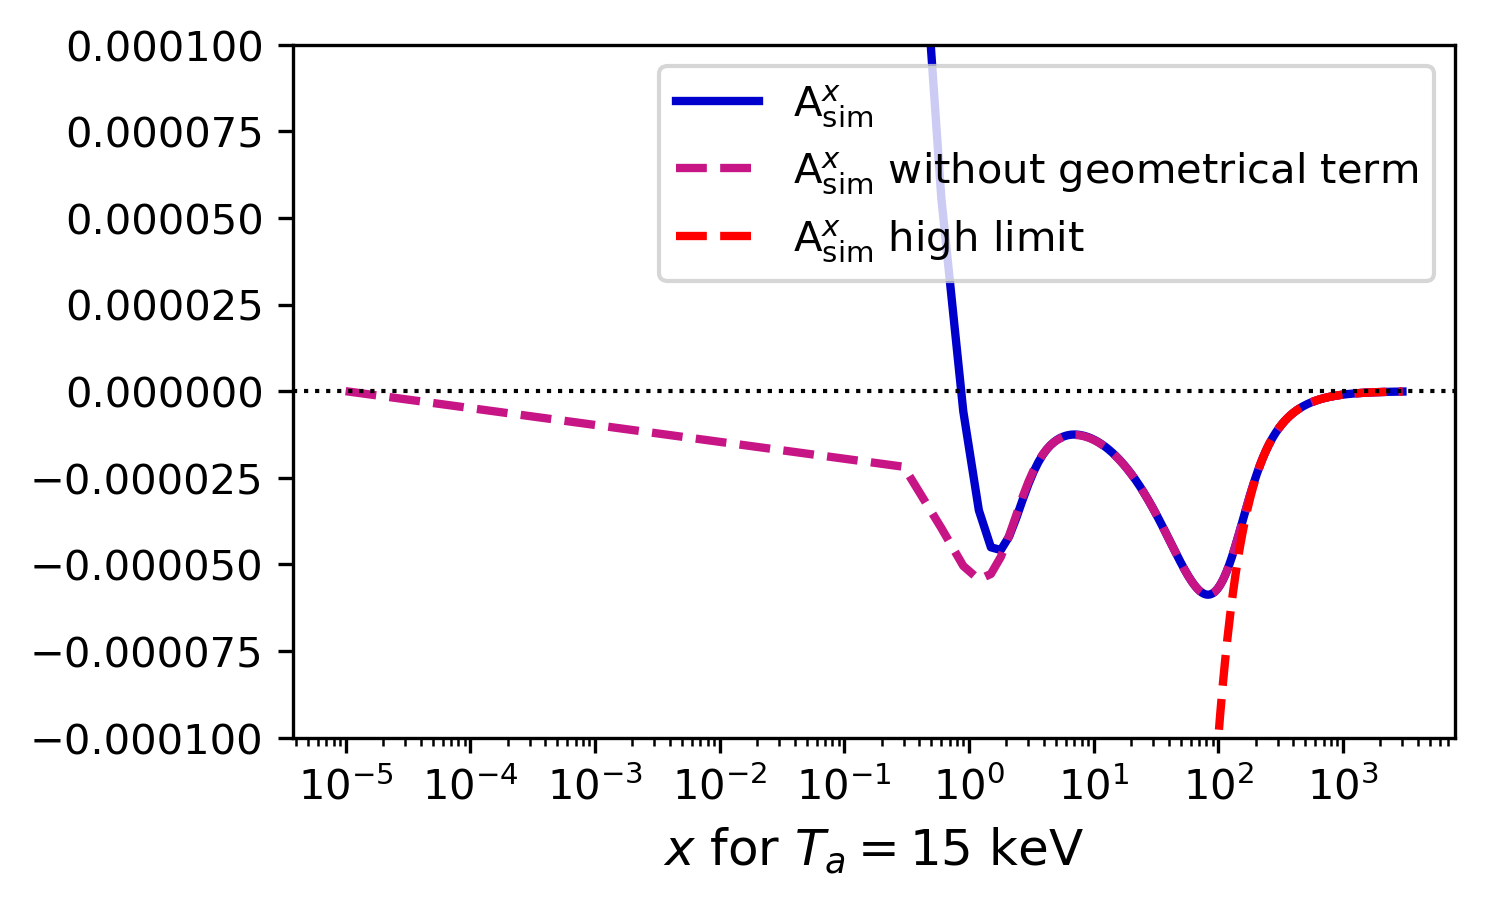

In [19]:
x = np.linspace(1e-5, 3000, 10000)

plt.figure(figsize=(5, 3), dpi=300)
plt.xlabel(r'$x$ for $T_a = 15~\text{keV}$', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(-1e-4, 1e-4)
plt.plot(x, Asimx(x), color='mediumblue', label=r'A$_{\text{sim}}^x$', linewidth=2)
plt.plot(x, Asimx_nogeom(x), color='mediumvioletred', label=r'A$_{\text{sim}}^x$ without geometrical term', linewidth=2, linestyle='--')
plt.plot(x, - ZPAR / x**2, color='red', label=r'A$_{\text{sim}}^x$ high limit', linewidth=2, linestyle='--')
plt.xscale('log')
plt.axhline(0, linestyle=':', color='black', linewidth=1)
plt.legend(fontsize=10)
plt.show()